3. In this problem, you will perform K-means clustering manually, with
K = 2, on a small example with n = 6 observations and p = 2
features. The observations are as follows.


| Obs. | X1 | X2 |
|:----:|:--:|:--:|
|  1   |  1 |  4 |
|  2   |  1 |  3 |
|  3   |  0 |  4 |
|  4   |  5 |  1 |
|  5   |  6 |  2 |
|  6   |  4 |  0 |

(a) Plot the observations.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

obs_ids = np.array([1,2,3,4,5,6])
X=np.array([
    [1,4],
    [1,3],
    [0,4],
    [5,1],
    [6,2],
    [4,0],
],dtype=float)

k=2
rng = np.random.default_rng(42)

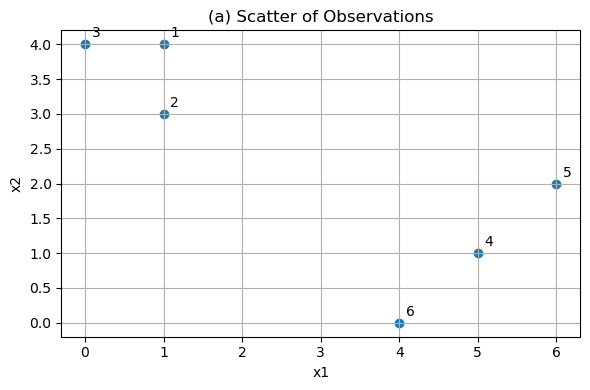

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0],X[:,1])
for i,(x,y) in enumerate(X,start=1):
    plt.annotate(str(i),(x,y),textcoords="offset points",xytext=(5,5))
plt.title("(a) Scatter of Observations")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.tight_layout()
plt.show()

(b) Randomly assign a cluster label to each observation. You can use
the np.random.choice() function to do this. Report the cluster
labels for each observation.

In [14]:
labels = rng.choice(np.arange(k), size=X.shape[0])

print("(b) initial random labels :")
for oid, lab in zip(obs_ids, labels):
    print(f" obs {oid}: cluster{lab}")

(b) initial random labels :
 obs 1: cluster0
 obs 2: cluster1
 obs 3: cluster1
 obs 4: cluster0
 obs 5: cluster0
 obs 6: cluster1


(c) Compute the centroid for each cluster.

In [22]:
def compute_centroids(X, labels, k=2, rng=None):
    C = np.zeros((k, X.shape[1]), dtype=float)
    for k in range(k):
        pts = X[labels==k]
        if len(pts)>0:
            C[k] = pts.mean(axis=0)
        else:
            idx = rng.integers(0, X.shape[0]) if rng is not None else np.random.randint (0,X.shape[0])
            C[k] = X[idx]
    return C
centroids = compute_centroids(X, labels, k=k, rng=rng)
print("(c) centroids (C0, C1):",centroids)            

(c) centroids (C0, C1): [[4.         2.33333333]
 [1.66666667 2.33333333]]


(d) Assign each observation to the centroid to which it is closest, in
terms of Euclidean distance. Report the cluster labels for each
observation

In [23]:
def assign_by_nearest_centroid(X, centroids):
    dists = np.stack([np.sum ((X-c)**2, axis=1) for c in centroids],axis=1)
    new_labels = np.argmin(dists, axis=1)
    return new_labels, dists

new_labels, dmat = assign_by_nearest_centroid(X, centroids)
print("(d) labels after nearest-centroid assignment:")
for oid, lab in zip(obs_ids, new_labels):
    print(f"Obs {oid}: cluster {lab}")
labels = new_labels

(d) labels after nearest-centroid assignment:
Obs 1: cluster 1
Obs 2: cluster 1
Obs 3: cluster 1
Obs 4: cluster 0
Obs 5: cluster 0
Obs 6: cluster 0


(e) Repeat (c) and (d) until the answers obtained stop changing.

In [26]:
max_iter = 50
for it in range(max_iter):
    centroids = compute_centroids(X,labels,k=k,rng=rng)
    new_labels,_ = assign_by_nearest_centroid(X, centroids)
    changed = not np.array_equal(new_labels, labels)
    print(f"(e) iter{it}: c0={centroids[0]},c1={centroids[1]}, changed{changed}")
    labels = new_labels
    if not changed:
        break
    
print("(e) fianl labels:")
for oid, lab in zip(obs_ids, labels):
    print(f"Obs {oid}: cluster{lab}")

(e) iter0: c0=[5. 1.],c1=[0.66666667 3.66666667], changedFalse
(e) fianl labels:
Obs 1: cluster1
Obs 2: cluster1
Obs 3: cluster1
Obs 4: cluster0
Obs 5: cluster0
Obs 6: cluster0


(f) In your plot from (a), color the observations according to the
cluster labels obtained.

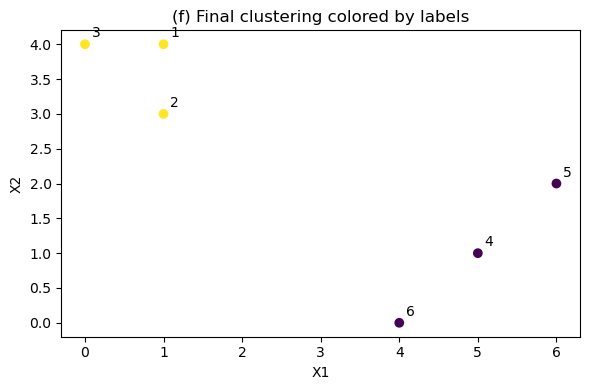

In [30]:

import matplotlib.pyplot as plt
import numpy as np

plt.figure (figsize=(6,4))
plt.scatter(X[:,0],X[:,1],c=labels)
for i, (px,py) in enumerate(X, start=1):
    plt.annotate(str(i), (px,py), textcoords = "offset points", xytext=(5,5))
plt.title("(f) Final clustering colored by labels")
plt.xlabel("X1")
plt.ylabel("X2")
plt.tight_layout()
plt.show()